# YOLOv8 finetuning notebook

This notebook fine-tunes a YOLOv8 detector to locate the plant region used for downstream cropping. It now resolves the dataset and output paths from the repository root at runtime.

## Input
- A dataset that we prepare in advance through a third-party source.
- Pretrained model


## Output
- Newly trained/fine-tuned model based on our data

## Procedure
1. Load train/validation/test set
2. Train the model
3. Run inference on the test set
4. Load real folder
5. Run inference and visualize each image

## Settings

**Important:** run this notebook in an environment with GPU support when possible.

Before training, verify that `data.yaml` points to the correct `train`, `val`, and `test` image folders inside the annotation directory. The Ultralytics package may also download a temporary compatibility-check model during setup; that file is only used for the AMP check and does not change the model you fine-tune here.

# FUNCTIONS

### Path, importing libraries

In [ ]:
from pathlib import Path
import random
import shutil

import cv2
import matplotlib.pyplot as plt
import ultralytics
from IPython.display import clear_output
from ultralytics import YOLO

# Advanced users: edit these paths directly in this notebook.
ROOT_PATH = Path("/home/vasakjakub/fenotypizace")
OBJECT_DETECTION_MODEL_DIR = ROOT_PATH / "models" / "object_detection_model"
YOLO_FINE_TUNING_DIR = OBJECT_DETECTION_MODEL_DIR / "fine_tuning"
YOLO_ANNOTATIONS_DIR = OBJECT_DETECTION_MODEL_DIR / "detect_annotations"
DATA_YAML_PATH = YOLO_ANNOTATIONS_DIR / "data.yaml"

clear_output()

print("Repo root:", ROOT_PATH)
print("YOLO annotations:", YOLO_ANNOTATIONS_DIR)
print("Fine-tuning dir:", YOLO_FINE_TUNING_DIR)
print("data.yaml:", DATA_YAML_PATH)
ultralytics.checks()

if not DATA_YAML_PATH.exists():
    raise FileNotFoundError(f"Missing data.yaml: {DATA_YAML_PATH}")

Ultralytics 8.3.70 🚀 Python-3.10.16 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 14918MiB)
Setup complete ✅ (8 CPUs, 29.4 GB RAM, 54.5/98.2 GB disk)


In [ ]:
root = str(ROOT_PATH) + "/"
save_model = f"{YOLO_FINE_TUNING_DIR}/"
yolo_annotations = f"{YOLO_ANNOTATIONS_DIR}/"

### Hyperparameters

In [3]:
n_epochs = 100

### Load Training/Validation data

This is the most important and time-consuming step. It is essential to have a precisely structured dataset compatible with YOLOv8. The dataset should consist of two folders: train and val, along with a data.yaml file. While there are various ways to generate this structure, we assume it has already been created and is ready to be used in this process. Our dataset was generated using Roboflow.

Data folder should have this structure:

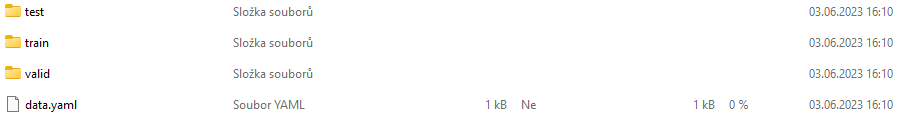

### Train

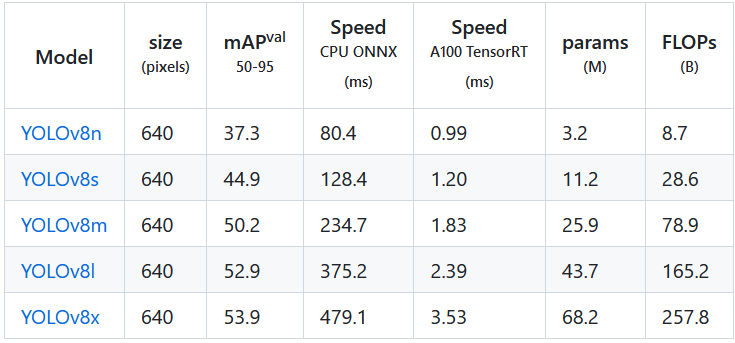


For the argument model, the selected model should follow the format model_name.pt, such as YOLOv8s.pt.

**If the functions trainModeln or trainModels do not work, the issue may be caused by an excessively long directory path in the argument. Copying data.yaml to the root folder can resolve this problem.**

In [ ]:
def train_model(
    yolo_annotations: str, save_model: str, n_epochs: int, mod_type: str
) -> None:
    """Train a YOLO model using the Ultralytics Python API."""
    results_dir = Path(save_model) / "runs" / "detect"
    data_yaml = Path(yolo_annotations) / "data.yaml"

    if results_dir.exists():
        shutil.rmtree(results_dir)

    model_weights = Path(save_model) / f"yolov8{mod_type}.pt"
    model = YOLO(str(model_weights))
    model.train(
        data=str(data_yaml),
        epochs=n_epochs,
        imgsz=800,
        plots=True,
        project=str(results_dir),
        name="train_results",
        save_dir=save_model,
    )


def predict_images(path_to_pretrained_model: str, yolo_annotations: str) -> None:
    """Run inference with a pretrained YOLO model on the test images."""
    test_images = Path(yolo_annotations) / "test" / "images"
    model = YOLO(path_to_pretrained_model)
    model.predict(
        str(test_images),
        save=True,
        conf=0.5,
        project=path_to_pretrained_model,
        name="predictions",
    )

In [ ]:
def visualize_random_annotation(yolo_annotations: str) -> None:
    """Visualize a random image with its YOLO annotations."""
    images_dir = Path(yolo_annotations) / "train" / "images"
    labels_dir = Path(yolo_annotations) / "train" / "labels"

    image_files = [path for path in images_dir.iterdir() if path.is_file()]

    if not image_files:
        print("No images found in the training directory.")
        return

    random_image = random.choice(image_files)
    img = cv2.imread(str(random_image))
    if img is None:
        raise FileNotFoundError(f"Could not load image: {random_image}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width, _ = img.shape

    label_path = labels_dir / f"{random_image.stem}.txt"

    print(f"Image: {random_image.name}")
    print(f"Dimensions: {width}x{height}")

    if label_path.exists():
        with label_path.open(encoding="utf-8") as handle:
            annotations = handle.readlines()

        print(f"Found {len(annotations)} annotations:")

        for annotation in annotations:
            values = annotation.strip().split()
            if len(values) >= 5:
                class_id = int(values[0])
                x_center = float(values[1]) * width
                y_center = float(values[2]) * height
                box_width = float(values[3]) * width
                box_height = float(values[4]) * height

                x1 = int(x_center - (box_width / 2))
                y1 = int(y_center - (box_height / 2))
                x2 = int(x_center + (box_width / 2))
                y2 = int(y_center + (box_height / 2))

                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(
                    img,
                    f"Class {class_id}",
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2,
                )

                print(
                    f"  Class {class_id}: center=({x_center:.1f}, {y_center:.1f}), "
                    f"width={box_width:.1f}, height={box_height:.1f}"
                )
    else:
        print(f"No label file found for {random_image.name}")

    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# EXECUTION

Image: 41_27-11-21-06-00-02_5-2_png.rf.4e19457d74a6d72e1dc17c3cbcd89a5d.jpg
Dimensions: 640x640
Found 1 annotations:
  Class 0: center=(213.0, 301.0), width=157.5, height=51.0


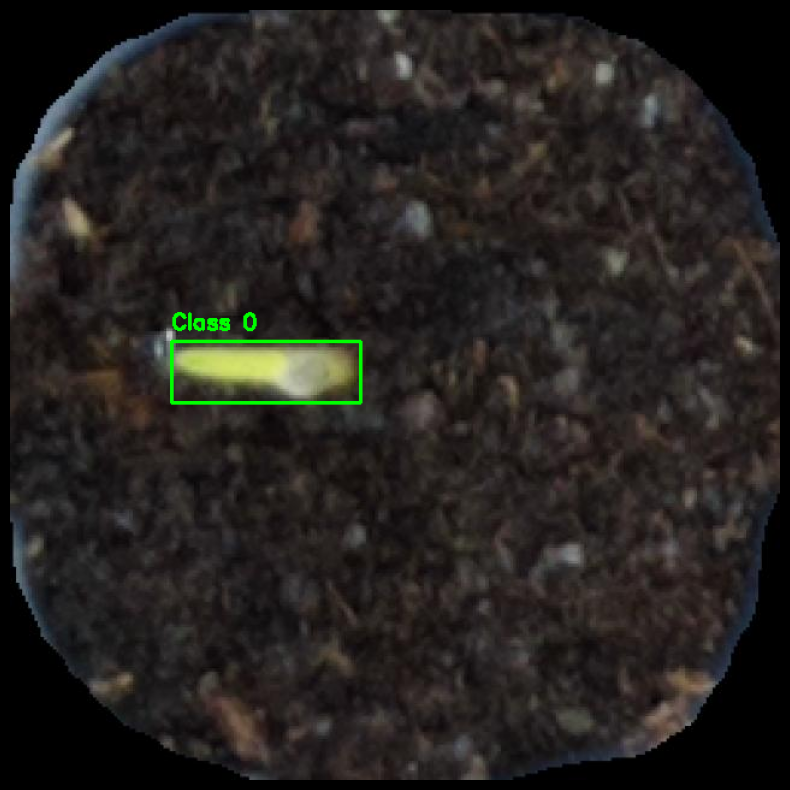

In [ ]:
# Check the saved annotations
visualize_random_annotation(yolo_annotations)

### YOLOv8n Model training

In [ ]:
# Set the type of the model
mod_type = "n"

train_model(yolo_annotations, save_model, n_epochs, mod_type)

100%|██████████| 6.25M/6.25M [00:00<00:00, 58.3MB/s]


New https://pypi.org/project/ultralytics/8.3.73 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.70 🚀 Python-3.10.16 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 14918MiB)
engine/trainer: task=detect, mode=train, model=/home/vasakjakub/emergence-detection/models/object_detection_model/fine_tuning/yolov8n.pt, data=/home/vasakjakub/emergence-detection/models/object_detection_model/detect_annotations//data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=/home/vasakjakub/emergence-detection/models/object_detection_model/fine_tuning/runs/detect, name=train_results, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=F

100%|██████████| 5.35M/5.35M [00:00<00:00, 182MB/s]


AMP: checks passed ✅


train: Scanning /home/vasakjakub/bucket/Fenotypizace/emergence-detection/models/object_detection_model/detect_annotations/train/labels.cache... 267 images, 10 backgrounds, 0 corrupt: 100%|██████████| 267/267 [00:00<?, ?it/s]
val: Scanning /home/vasakjakub/bucket/Fenotypizace/emergence-detection/models/object_detection_model/detect_annotations/valid/labels.cache... 43 images, 1 backgrounds, 0 corrupt: 100%|██████████| 43/43 [00:00<?, ?it/s]


...

    100/100      3.24G     0.3917     0.3041     0.8351         11        800: 100%|██████████| 17/17 [00:05<00:00,  3.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  6.84it/s]

                   all         43         42      0.974      0.875      0.925      0.636



100 epochs completed in 0.399 hours.
Optimizer stripped from /home/vasakjakub/emergence-detection/models/object_detection_model/fine_tuning/runs/detect/train_results/weights/last.pt, 6.3MB
Optimizer stripped from /home/vasakjakub/emergence-detection/models/object_detection_model/fine_tuning/runs/detect/train_results/weights/best.pt, 6.3MB

Validating /home/vasakjakub/emergence-detection/models/object_detection_model/fine_tuning/runs/detect/train_results/weights/best.pt...
Ultralytics 8.3.70 🚀 Python-3.10.16 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 14918MiB)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  5.29it/s]


                   all         43         42      0.953      0.966      0.963      0.682
Speed: 0.3ms preprocess, 5.3ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /home/vasakjakub/emergence-detection/models/object_detection_model/fine_tuning/runs/detect/train_results


In [ ]:
# Rename the best.pt file to the desired name
renamed_model = Path(save_model) / "germination_detector.pt"
best_model = (
    Path(save_model) / "runs" / "detect" / "train_results" / "weights" / "best.pt"
)
best_model.rename(renamed_model)

predict_images(str(renamed_model), yolo_annotations)


image 1/22 /home/vasakjakub/emergence-detection/models/object_detection_model/detect_annotations/test/images/10_2019-12-05-06-09-45_7-6_png.rf.c3f03b79b06b5e6976c8cd47c48c3595.jpg: 800x800 1 plant, 10.1ms
image 2/22 /home/vasakjakub/emergence-detection/models/object_detection_model/detect_annotations/test/images/11_28-11-21-12-00-02_5-8_png.rf.b9224dd15440ed04046b94a5007e203e.jpg: 800x800 1 plant, 10.1ms
image 3/22 /home/vasakjakub/emergence-detection/models/object_detection_model/detect_annotations/test/images/12_2019-12-05-02-03-25_1-7_png.rf.8c44bf23afb2800518833a69b4dcd33a.jpg: 800x800 1 plant, 10.1ms
image 4/22 /home/vasakjakub/emergence-detection/models/object_detection_model/detect_annotations/test/images/12_2019-12-06-20-29-14_4-4_png.rf.517ef61acf376760322c9f0d3e5eaa69.jpg: 800x800 1 plant, 10.1ms
image 5/22 /home/vasakjakub/emergence-detection/models/object_detection_model/detect_annotations/test/images/13_2019-12-05-06-10-18_7-4_png.rf.7ecaf51b41d98c72c3635002e88f30ff.jpg: 